# Check the impact of analyst forecasts on residualized returns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

pd.set_option("display.max_columns", 100)

In [2]:
characteristics = pd.read_parquet("Data/Statistical_loadings/characteristics_gamma_1.parquet")
factors = pd.read_parquet("Data/Statistical_loadings/factors_gamma_1.parquet")
residuals = pd.read_parquet("Data/Statistical_loadings/residuals_gamma_1.parquet")
total_returns = pd.read_hdf("Data/daily_returns_SPX.h5")

In [3]:
# Full reconstruction check using past characteristics.
# For each return date d, use characteristics from the previous trading date.
common_dates = factors.index.intersection(residuals.index).intersection(total_returns.index)
tickers = residuals.columns.intersection(total_returns.columns)
characteristic_dates = characteristics.index.get_level_values("Date").unique()

reconstructed_rows = []
missing_characteristic_dates = []

for return_date in common_dates:
    previous_pos = total_returns.index.get_loc(return_date) - 1
    if previous_pos < 0:
        continue

    characteristic_date = total_returns.index[previous_pos]
    if characteristic_date not in characteristic_dates:
        missing_characteristic_dates.append((return_date, characteristic_date))
        continue

    B_prev = characteristics.xs(characteristic_date, level="Date").loc[tickers].to_numpy(dtype=float)
    f_t = factors.loc[return_date].to_numpy(dtype=float)
    eps_t = residuals.loc[return_date, tickers].to_numpy(dtype=float)
    reconstructed_rows.append(
        pd.Series(B_prev @ f_t + eps_t, index=tickers, name=return_date)
    )

reconstructed_returns = pd.DataFrame(reconstructed_rows)
actual_returns = total_returns.loc[reconstructed_returns.index, tickers].astype(float)
reconstruction_error = reconstructed_returns - actual_returns

max_abs_error = reconstruction_error.abs().max().max()
max_error_location = reconstruction_error.abs().stack().idxmax()
atol = 1e-10

print(f"Checked {reconstruction_error.shape[0]} dates x {reconstruction_error.shape[1]} assets")
print(f"Max abs error: {max_abs_error:.3e}")
print(f"Max error location: date={max_error_location[0].date()}, ticker={max_error_location[1]}")
print(f"All close with atol={atol}: {np.allclose(reconstructed_returns, actual_returns, atol=atol, rtol=0)}")

if missing_characteristic_dates:
    print(f"Skipped {len(missing_characteristic_dates)} dates with missing past characteristics")

# reconstruction_error.abs().describe().T.sort_values("max", ascending=False).head(10)
residuals.head()


Checked 1713 dates x 428 assets
Max abs error: 1.110e-16
Max error location: date=2019-10-10, ticker=PCG
All close with atol=1e-10: True


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,AON,AOS,APD,APH,APO,APTV,ARE,ARES,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BALL,BAX,BBY,...,TRGP,TRMB,TROW,TRV,TSCO,TSLA,TSN,TT,TTWO,TXN,TXT,TYL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VTRS,VZ,WAB,WAT,WDC,WEC,WELL,WFC,WM,WMB,WRB,WSM,WST,WTW,WY,WYNN,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-05-14,0.016964,-0.002740,0.014002,-0.002615,0.011418,0.004211,-0.005144,0.008563,0.006550,-0.002348,0.006622,-0.003036,-0.002869,0.008852,0.008646,0.006858,0.001331,0.001590,0.012874,0.015573,0.000477,-0.004897,0.003726,0.011282,0.002262,-0.007396,0.007093,0.005835,-0.012655,-0.005581,0.004768,-0.007494,-0.000655,-0.008092,0.020336,0.006129,0.005912,-0.005720,-0.005207,-0.004920,0.016353,-0.009808,-0.001575,-0.001158,0.004005,0.004050,-0.002330,-0.018309,-0.001417,-0.008310,...,0.009282,-0.004690,0.006972,0.012487,0.000690,0.005554,0.022302,-0.000911,0.016132,0.001062,0.008923,-0.011043,-0.000562,-0.001272,0.002675,-0.021815,0.006484,-0.004815,-0.014734,-0.003400,0.002552,0.019255,0.000211,-0.002149,-0.002353,-0.000671,0.002774,-0.002885,-0.001830,-0.022159,0.000825,0.013595,0.003182,0.006564,-0.006206,-0.004239,0.002028,0.001178,0.001629,-0.018923,0.004117,-0.014923,-0.010471,-0.005203,-0.024285,-0.006485,-0.002585,-0.008528,0.009802,-0.010008
2019-05-15,-0.113311,0.000792,0.004386,0.004159,0.005268,0.005821,0.005923,0.004746,0.000403,0.001152,0.006262,-0.004607,0.002432,0.005815,0.012507,0.002190,0.003823,0.003272,-0.013561,0.005950,0.009886,0.008482,0.029472,-0.013716,0.006066,0.012781,0.000745,0.005971,0.003783,-0.016562,0.005117,-0.007355,-0.005717,0.006042,-0.002992,0.000235,0.006253,0.010631,-0.008807,0.001109,0.001584,-0.004346,0.000853,0.005629,-0.015087,0.003883,-0.005032,-0.017153,-0.002516,-0.004313,...,0.011868,-0.013495,0.005802,0.008786,-0.018588,-0.012912,0.004939,-0.000871,0.024264,0.003450,-0.002408,0.003057,0.001151,-0.005394,0.012457,-0.000542,-0.008142,0.013068,0.007499,0.000211,0.008125,-0.000616,-0.002389,0.007270,0.007683,-0.002291,0.005514,-0.019367,0.003726,-0.017511,-0.019503,0.004177,-0.001382,0.000922,-0.008653,0.006747,0.004327,0.004787,-0.010434,-0.000505,0.002549,-0.007937,0.006852,0.005394,0.010225,-0.003998,-0.001326,-0.004793,-0.021271,0.001102
2019-05-16,0.017134,-0.013311,0.001302,-0.007182,0.004627,0.001951,-0.001748,-0.019301,0.004407,-0.005303,0.004594,-0.001863,0.000097,0.004992,0.000667,-0.003744,0.002117,0.005766,-0.002864,0.008602,-0.006739,0.005995,0.014842,0.023468,0.001086,0.002737,0.006132,-0.000004,0.000207,0.007781,0.003679,-0.062740,0.015940,-0.009626,0.002672,-0.020075,-0.002546,-0.000915,0.001197,0.003428,-0.019668,-0.008295,-0.001086,0.004305,0.002174,0.010484,-0.003805,-0.004760,0.009248,0.007788,...,-0.006321,0.005711,0.000235,-0.003197,0.008416,-0.024038,-0.001715,-0.003609,-0.020464,-0.001755,0.009870,-0.001336,-0.001998,-0.005172,0.000354,-0.005660,-0.001400,-0.006861,-0.010985,0.005131,-0.002379,0.016321,-0.000878,-0.007182,-0.002434,0.012181,0.003849,0.013384,0.005139,-0.005644,0.004075,0.005401,0.000332,0.005870,-0.007605,-0.004466,-0.006452,-0.002213,0.007044,-0.004619,0.006293,-0.000383,0.018702,-0.007544,-0.012281,-0.011372,-0.007489,-0.008301,0.012470,0.002080
2019-05-17,0.008110,0.010391,0.002417,-0.001885,-0.017377,0.007452,-0.001109,-0.017198,-0.010766,0.004580,0.007144,-0.000582,-0.000111,0.005071,0.010867,-0.013151,-0.005038,0.004571,-0.005040,-0.003374,-0.001796,-0.004274,0.051364,0.012691,0.007756,0.003753,0.001664,-0.001210,-0.003067,0.000698,-0.005937,-0.008179,0.010613,-0.002690,0.006315,0.016903,-0.001294,0.006507,0.005275,-0.000224,-0.011865,0.001223,0.002265,-0.001373,0.001453,0.017834,-0.000164,0.005506,-0.006853,0.011282,...,0.008025,-0.005631,-0.000107,0.002319,-0.002293,-0.063809,-0.001500,0.003735,0.007291,-0.003421,-

In [4]:
analyst_data = pd.read_csv("Data/firm_level.csv")
analyst_data["actual_release_date"] = pd.to_datetime(analyst_data["actual_release_date"])
release_dates = analyst_data["actual_release_date"].unique()
common_dates = np.sort(np.array(list(set(residuals.index) & set(release_dates))))
# print(common_dates.shape, residuals.shape[0])
# analyst_data.head()
analyst_tickers = np.sort(analyst_data["ticker"].unique())
resid_tickers = np.array(list(residuals.columns))
common_tickers = np.sort(np.array(list(set(analyst_tickers) & set(resid_tickers))))
resids = residuals[common_tickers]
analysts = analyst_data[analyst_data["ticker"].isin(common_tickers)]
analysts = analysts.drop(columns= ["cwiq_code","fiscal_year.1","fiscal_quarter.1","ticker.1","eps_mad","rev_mad"])
# analysts = analysts.set_index("actual_release_date")

In [5]:
print(resids.index[0], resids.index[-1])
analysts.head()

2019-05-14 00:00:00 2026-03-06 00:00:00


,fiscal_year,fiscal_quarter,ticker,instrument_sector,instrument_industry,actual_release_date,reported_eps,reported_revenue,price_before_announcement,price_after_announcement,Trading Volume Before Announcement,Trading Volume After Announcement,eps_mean,eps_median,eps_std,eps_skew,eps_kurtosis,eps_p10,eps_p25,eps_p75,eps_p90,eps_mode,eps_num_peaks,eps_entropy,rev_mean,rev_median,rev_std,rev_skew,rev_kurtosis,rev_p10,rev_p25,rev_p75,rev_p90,rev_mode,rev_num_peaks,rev_entropy
116,2015,3,AWK,Utilities,Water Utilities,2015-11-04,0.96,896.206,57.73,57.70,1000108.0,1076505.0,0.942000,0.95,0.011662,-1.150049,-0.333910,0.928,0.940,0.95,0.950,0.947879,1,4.518945,901.288000,909.330,12.455075,-0.794086,-0.982077,885.73,894.7000,910.3300,911.530,908.710000,1,4.565117
117,2015,4,AWK,Utilities,Water Utilities,2016-02-25,0.55,783.000,66.69,67.60,1178897.0,1350979.0,0.558182,0.56,0.014025,-0.465726,-0.569910,0.540,0.550,0.57,0.570,0.562828,1,4.552706,781.594545,785.250,12.185578,-1.405203,1.471350,770.00,778.8550,787.7450,793.340,785.972222,2,4.393841
118,2016,1,AWK,Utilities,Water Utilities,2016-05-04,0.46,743.000,73.93,73.80,1372881.0,1408962.0,0.462143,0.46,0.010809,-0.093496,-0.389962,0.450,0.460,0.47,0.477,0.461010,1,4.535486,730.722143,732.490,4.684897,-0.797714,-0.349566,725.06,727.4525,734.1650,735.336,733.478788,1,4.513581
119,2016,2,AWK,Utilities,Water Utilities,2016-08-03,0.77,827.000,82.07,82.13,913045.0,1069048.0,0.733750,0.73,0.015762,1.475375,1.997152,0.720,0.720,0.74,0.750,0.726061,2,4.314644,839.755625,840.075,3.717217,0.255157,-1.040908,835.15,835.9600,842.1975,844.840,840.841818,2,4.582174
120,2016,3,AWK,Utilities,Water Utilities,2016-11-02,1.05,930.000,73.05,72.99,1169560.0,1063606.0,1.000667,1.00,0.016111,-0.682208,0.813544,0.984,0.995,1.01,1.016,1.003131,1,4.433113,935.358000,933.150,5.843171,1.210419,0.666021,930.02,931.8100,937.7550,943.448,932.784848,1,4.430226


In [6]:
import pandas_market_calendars as mcal

calendars = mcal.get_calendar("NYSE")
business_days = calendars.schedule(start_date = '2019-05-14', end_date = '2026-03-06')
analysts = analysts[analysts["actual_release_date"].isin(business_days.index)]
analysts1 = analysts.set_index(["actual_release_date","ticker"])
analysts1 = analysts1.sort_index(level = 0)

In [7]:
resids_stack = resids.stack()

In [8]:
resid_dates_sorted = pd.DatetimeIndex(resids.index.sort_values())

df = analysts.reset_index()
resid_release = resids.stack().rename("resid_release_date")
resid_release.index = resid_release.index.set_names(["actual_release_date", "ticker"])
df = df.join(resid_release, on=["actual_release_date", "ticker"])

# Next available trading day in resids after each release date
positions = resid_dates_sorted.searchsorted(df["actual_release_date"].values, side="right")
in_bounds = positions < len(resid_dates_sorted)
safe_pos = np.where(in_bounds, positions, 0)
next_dates = pd.Series(resid_dates_sorted[safe_pos], index=df.index)
next_dates[~in_bounds] = pd.NaT
df["_next_resid_date"] = next_dates

# Residual return on next trading day
resid_next = resids.stack().rename("resid_next_day")
resid_next.index = resid_next.index.set_names(["_next_resid_date", "ticker"])
df = df.join(resid_next, on=["_next_resid_date", "ticker"])
df = df.drop(columns=["_next_resid_date"])

# Drop rows where either residual is unavailable
df = df.dropna(subset=["resid_release_date", "resid_next_day"])

analysts1 = df.set_index(["actual_release_date","ticker"])
analysts1 = analysts1.sort_index(level = 0)
analysts1.head()

index  fiscal_year  fiscal_quarter  \
actual_release_date ticker                                       
2019-05-15          CSCO     9022         2019               3   
2019-05-16          AMAT     3942         2019               2   
                    NVDA    21598         2020               1   
2019-05-17          DE       9866         2019               2   
2019-05-20          NDSN    20833         2019               2   

                                 instrument_sector       instrument_industry  \
actual_release_date ticker                                                     
2019-05-15          CSCO    Information Technology  Communications Equipment   
2019-05-16          AMAT    Information Technology            Semiconductors   
                    NVDA    Information Technology            Semiconductors   
2019-05-17          DE                 Industrials                 Machinery   
2019-05-20          NDSN               Industrials                 Machinery   

                            reported_eps  reported_revenue  \
actual_release_date ticker                                   
2019-05-15          CSCO            0.78         12958.000   
2019-05-16          AMAT            0.70          3539.000   
                    NVDA            0.16          2220.000   
2019-05-17          DE              3.52         11342.000   
2019-05-20          NDSN            1.54           551.119   

                            price_before_announcement  \
actual_release_date ticker                              
2019-05-15          CSCO                        52.02   
2019-05-16          AMAT                        41.50   
                    NVDA                       159.58   
2019-05-17          DE                         140.00   
2019-05-20          NDSN                       135.23   

                            price_after_announcement  \
actual_release_date ticker                             
2019-05-15          CSCO                       51.79   
2019-05-16          AMAT                       41.30   
                    NVDA                      159.44   
2019-05-17          DE                        134.82   
2019-05-20          NDSN                      133.39   

                            Trading Volume Before Announcement  \
actual_release_date ticker                                       
2019-05-15          CSCO                            25478278.0   
2019-05-16          AMAT                            12050984.0   
                    NVDA                            12558001.0   
2019-05-17          DE                               2893384.0   
2019-05-20          NDSN                              275534.0   

                            Trading Volume After Announcement  eps_mean  \
actual_release_date ticker                                                
2019-05-15          CSCO                           30577207.0  0.777500   
2019-05-16          AMAT                           11932487.0  0.768615   
                    NVDA                           19527204.0  0.255327   
2019-05-17          DE                              7817465.0  3.566667   
2019-05-20          NDSN                             570516.0  1.580000   

                            eps_median   eps_std  eps_skew  eps_kurtosis  \
actual_release_date ticker                                                 
2019-05-15          CSCO        0.7800  0.021100 -1.214563      2.982118   
2019-05-16          AMAT        0.6900  0.158947  1.642877      1.208264   
                    NVDA        0.2175  0.094281  2.068994      3.348012   
2019-05-17          DE          3.5500  0.149518  3.122342     11.541239   
2019-05-20          NDSN        1.5900  0.045216 -0.613006     -0.791470   

                            eps_p10  eps_p25  eps_p75  eps_p90  eps_mode  \
actual_release_date ticker                                                 
2019-05-15          CSCO      0.750   0.7700     0.79    0.800  0.783333   
2019-05-16          AMAT  

In [9]:

analysts1["eps_surprise"] = analysts1["reported_eps"] - analysts1["eps_median"]

analysts1["eps_relative_surprise"] = (
    analysts1["eps_surprise"] / analysts1["eps_median"].abs()
).replace([np.inf, -np.inf], np.nan)

# Surprise normalized by analyst dispersion (SUE-style z-score)
analysts1["eps_sue"] = (
    analysts1["eps_surprise"] / analysts1["eps_std"]
).replace([np.inf, -np.inf], np.nan)

# Analyst disagreement as coefficient of variation
analysts1["eps_dispersion"] = (
    analysts1["eps_std"] / analysts1["eps_mean"].abs()
).replace([np.inf, -np.inf], np.nan)

# --- Revenue features ---
analysts1["rev_surprise"] = analysts1["reported_revenue"] - analysts1["rev_mean"]

analysts1["rev_relative_surprise"] = (
    analysts1["rev_surprise"] / analysts1["rev_mean"].abs()
).replace([np.inf, -np.inf], np.nan)

analysts1["rev_sue"] = (
    analysts1["rev_surprise"] / analysts1["rev_std"]
).replace([np.inf, -np.inf], np.nan)

analysts1["rev_dispersion"] = (
    analysts1["rev_std"] / analysts1["rev_mean"].abs()
).replace([np.inf, -np.inf], np.nan)

# --- Price / intraday features ---
# Intraday return on the release date (after vs before announcement price)
analysts1["intraday_return"] = (
    analysts1["price_after_announcement"] / analysts1["price_before_announcement"] - 1
)

# Residual return on release date already captured in resid_release_date

# --- Volume feature ---
analysts1["volume_ratio"] = (
    analysts1["Trading Volume After Announcement"]
    / analysts1["Trading Volume Before Announcement"]
).replace([np.inf, -np.inf], np.nan)

new_features = ["eps_surprise", "eps_relative_surprise", "eps_sue", "eps_dispersion",
           "rev_surprise", "rev_relative_surprise", "rev_sue", "rev_dispersion",
           "intraday_return", "volume_ratio", "resid_release_date", "resid_next_day"] 
analysts1[new_features].head(10)

eps_surprise  eps_relative_surprise   eps_sue  \
actual_release_date ticker                                                  
2019-05-15          CSCO          0.0000               0.000000  0.000000   
2019-05-16          AMAT          0.0100               0.014493  0.062914   
                    NVDA         -0.0575              -0.264368 -0.609876   
2019-05-17          DE           -0.0300              -0.008451 -0.200645   
2019-05-20          NDSN         -0.0500              -0.031447 -1.105815   
2019-05-21          AZO           0.7650               0.050246  1.387353   
                    HD            0.0500               0.022523  0.801349   
                    TJX           0.0000               0.000000  0.000000   
2019-05-22          ADI           0.0400               0.030303  1.322407   
                    CPRT          0.0400               0.064516  6.047432   

                            eps_dispersion  rev_surprise  \
actual_release_date ticker                                 
2019-05-15          CSCO          0.027139    113.007721   
2019-05-16          AMAT          0.206797    -93.046154   
                    NVDA          0.369258   -322.571895   
2019-05-17          DE            0.041921   1117.592593   
2019-05-20          NDSN          0.028617     -6.977667   
2019-05-21          AZO           0.035907     22.300000   
                    HD            0.028076    -14.762500   
                    TJX           0.082975    -47.611111   
2019-05-22          ADI           0.022870      3.434783   
                    CPRT          0.010712     13.361000   

                            rev_relative_surprise   rev_sue  rev_dispersion  \
actual_release_date ticker                                                    
2019-05-15          CSCO                 0.008798  0.101877        0.086357   
2019-05-16          AMAT                -0.025618 -0.270357        0.094756   
                    NVDA                -0.126868 -0.152136        0.833916   
2019-05-17          DE                   0.109306  4.438094        0.024629   
2019-05-20          NDSN                -0.012503 -2.196696        0.005692   
2019-05-21          AZO                  0.008078  0.734726        0.010994   
                    HD                  -0.000559 -0.059040        0.009473   
                    TJX                 -0.005105 -0.247564        0.020623   
2019-05-22          ADI                  0.002254  0.150076        0.015022   
                    CPRT                 0.024754  2.116924        0.011693   

                            intraday_return  volume_ratio  resid_release_date  \
actual_release_date ticker                                                      
2019-05-15          CSCO          -0.004421      1.200128            0.001195   
2019-05-16          AMAT          -0.004819      0.990167            0.014842   
                    NVDA          -0.000877      1.554961            0.004895   
2019-05-17          DE            -0.037000      2.701842           -0.054096   
2019-05-20          NDSN          -0.013606      2.070583           -0.024130   
2019-05-21          AZO            0.028701      1.632653            0.048397   
                    HD             0.023797      1.788895           -0.010344   
                    TJX           -0.004300      1.259620           -0.003688   
2019-05-22          ADI            0.026305      1.118728            0.024386   
                    CPRT           0.004246      1.543800           -0.014350   

                            resid_next_day  
actual_release_date ticker                  
2019-05-15          CSCO          0.051862  
2019-05-16          AMAT          0.051364  
                    NVDA          0.002101  
2019-05-17          DE            0.020307  
2019-05-20          NDSN          0.009235  
2019-05-21          AZO           0.017756  
                    HD           -0.004729  
                    TJX          -0.023488  
2019-05-22

In [10]:
import statsmodels.api as sm

In [11]:
print(analysts1[new_features].corr()["resid_next_day"].iloc[:-1])
corr_mat = analysts1[new_features].corr()
corr_mat[corr_mat > 0.05]

eps_surprise             0.075950
eps_relative_surprise    0.033137
eps_sue                  0.005387
eps_dispersion          -0.002966
rev_surprise             0.046235
rev_relative_surprise    0.059001
rev_sue                  0.039898
rev_dispersion           0.016026
intraday_return         -0.014280
volume_ratio            -0.021195
resid_release_date       0.001874
Name: resid_next_day, dtype: float64


,eps_surprise,eps_relative_surprise,eps_sue,eps_dispersion,rev_surprise,rev_relative_surprise,rev_sue,rev_dispersion,intraday_return,volume_ratio,resid_release_date,resid_next_day
eps_surprise,1.000000,0.323426,NaN,NaN,NaN,0.188788,0.076784,NaN,NaN,NaN,0.138689,0.075950
eps_relative_surprise,0.323426,1.000000,NaN,NaN,NaN,0.084136,NaN,NaN,NaN,NaN,0.064288,NaN
eps_sue,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eps_dispersion,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rev_surprise,NaN,NaN,NaN,NaN,1.000000,0.105357,NaN,NaN,NaN,NaN,NaN,NaN
rev_relative_surprise,0.188788,0.084136,NaN,NaN,0.105357,1.000000,0.144968,NaN,NaN,NaN,0.072531,0.059001
rev_sue,0.076784,NaN,NaN,NaN,NaN,0.144968,1.000000,NaN,NaN,NaN,NaN,NaN
rev_dispersion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
intraday_return,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.559607,NaN
volume_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [12]:
regression_features = ["eps_surprise","volume_ratio"]
from sklearn.model_selection import train_test_split
analysts1_ = analysts1.dropna(subset=regression_features)
X,y = analysts1_[regression_features],analysts1_["resid_next_day"]
# X["interaction"] = X[regression_features[0]]*X[regression_features[1]]
X = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
ols = sm.OLS(endog= y_train, exog= X_train).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         resid_next_day   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     10.95
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.82e-05
Time:                        10:03:39   Log-Likelihood:                 6235.4
No. Observations:                3377   AIC:                        -1.246e+04
Df Residuals:                    3374   BIC:                        -1.245e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0004      0.002      0.274      0.784      -0.003       0.004
eps_surprise     0.0055      0.001      4.657      0.000       0.003       0.008
volume_ratio    -0.0005      0.001     -0.511      0.609      -0.002       0.001
==============================================================================
Omnibus:                      529.653   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9190.219
Skew:                          -0.064   Prob(JB):                         0.00
Kurtosis:                      11.081   Cond. No.                         5.43
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
oos_rss = np.mean((y_test - ols.predict(X_test))**2)
oos_r_squared = 1 - oos_rss/np.var(y_test)
print(oos_r_squared)

0.004806100793212087


In [14]:
from sklearn.model_selection import TimeSeriesSplit

# Same data prep as the regression above, sorted by date for temporal splits
analysts1_cv = analysts1.dropna(subset=regression_features + ["resid_next_day"])
analysts1_cv = analysts1_cv.sort_index(level=0)

X_cv = sm.add_constant(analysts1_cv[regression_features])
y_cv = analysts1_cv["resid_next_day"].values

tscv = TimeSeriesSplit(n_splits=5)
oos_r2_folds = []

# for fold, (train_idx, test_idx) in enumerate(tscv.split(X_cv)):
#     print(f"test -> [{test_idx[0]},{test_idx[-1]}]")
#     print(f"train -> [{train_idx[0]},{train_idx[-1]}]")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_cv)):
    X_tr, X_te = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_tr, y_te = y_cv[train_idx], y_cv[test_idx]

    model = sm.OLS(endog=y_tr, exog=X_tr).fit()
    y_pred = model.predict(X_te)

    fold_r2 = 1 - np.mean((y_te - y_pred) ** 2) / np.var(y_te)
    oos_r2_folds.append(fold_r2)
    print(f"Fold {fold + 1}: OOS R² = {fold_r2:.4%}  (n_train={len(train_idx)}, n_test={len(test_idx)})")

print(f"\nMean OOS R²: {np.mean(oos_r2_folds):.4%}")
print(f"Std  OOS R²: {np.std(oos_r2_folds):.4%}")

Fold 1: OOS R² = -3.1347%  (n_train=841, n_test=840)
Fold 2: OOS R² = -3.3656%  (n_train=1681, n_test=840)
Fold 3: OOS R² = 0.7580%  (n_train=2521, n_test=840)
Fold 4: OOS R² = 0.7114%  (n_train=3361, n_test=840)
Fold 5: OOS R² = 0.5861%  (n_train=4201, n_test=840)

Mean OOS R²: -0.8889%
Std  OOS R²: 1.9301%


In [15]:
tscv = TimeSeriesSplit(n_splits=5, max_train_size=2000, test_size=500)

oos_r2_folds = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_cv)):
    X_tr, X_te = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_tr, y_te = y_cv[train_idx], y_cv[test_idx]

    model = sm.OLS(y_tr, X_tr).fit()
    y_pred = model.predict(X_te)
    fold_r2 = 1 - np.sum((y_te - y_pred)**2) / np.sum((y_te - y_te.mean())**2)
    oos_r2_folds.append(fold_r2)
    print(f"Fold {fold+1}: OOS R²={fold_r2:.4%}  n_train={len(train_idx)}  n_test={len(test_idx)}")

print(f"\nMean OOS R²: {np.mean(oos_r2_folds):.4%}")
print(f"Std  OOS R²: {np.std(oos_r2_folds):.4%}")

Fold 1: OOS R²=0.9311%  n_train=2000  n_test=500
Fold 2: OOS R²=0.4448%  n_train=2000  n_test=500
Fold 3: OOS R²=-0.0659%  n_train=2000  n_test=500
Fold 4: OOS R²=-0.1529%  n_train=2000  n_test=500
Fold 5: OOS R²=0.7311%  n_train=2000  n_test=500

Mean OOS R²: 0.3777%
Std  OOS R²: 0.4275%


-0.14192101997829476
0.025317690566071915
0.06225356710727749
0.0017930430238796255 0.0013911952842430412
0.001747647315429387 0.0015886351379718073


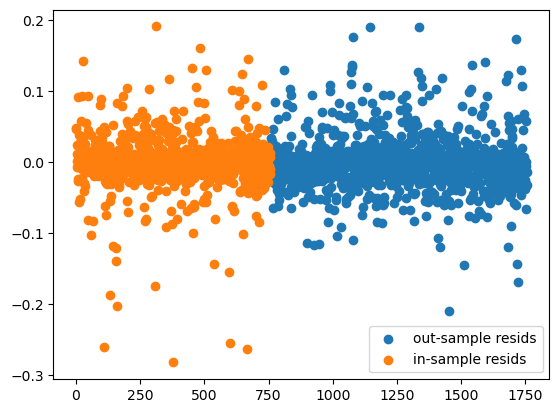

In [16]:
x_train,y_train = X_cv.iloc[:758,:].values, y_cv[:758]
x_test, y_test = X_cv.iloc[758:1757,:].values, y_cv[758:1757]
ols_m =  sm.OLS(endog = y_train, exog = x_train).fit()
oos_resid = y_test - ols_m.predict(x_test)
oos_r_squared = 1 - np.mean(oos_resid**2)/np.var(y_test)
print(oos_r_squared)
print(ols_m.rsquared)
print(np.corrcoef(ols_m.predict(x_test), y_test)[0,1])
print(np.var(y_train),np.var(y_test))
print(np.mean(ols_m.resid**2),np.mean(oos_resid**2))
plt.scatter(np.arange(x_train.shape[0],x_train.shape[0]+999),oos_resid,label = "out-sample resids")
plt.scatter(np.arange(x_train.shape[0]),ols_m.resid, label = "in-sample resids")
plt.legend()
plt.show()

In [17]:
from scipy.stats import rankdata

y_pred = ols_m.predict(x_test)
y_pred_ranked = rankdata(y_pred) / len(y_pred)
y_pred_scaled = (y_pred - y_pred.mean()) / y_pred.std() * y_test.std()
r2_scaled = 1 - np.sum((y_test - y_pred_scaled)**2) / np.sum((y_test - y_test.mean())**2)
print(r2_scaled)
print(np.corrcoef(y_pred_scaled,y_test)[0,1])
print(2*np.corrcoef(y_pred_scaled,y_test)[0,1]-1)

-0.8769163811450835
0.06225356710727749
-0.875492865785445
